# Training LF NN

In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam,Nadam,Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, kCrossValSingle
from time import perf_counter
import pandas
import os
seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
########################     PREPARATION      ##########################

Nlf_models = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young_new/N_bases.txt").astype(int)   #list of number of bases
U_train_LF_full = np.abs(np.loadtxt("../DATA_shear_cube/Data_Train_bases_young_new/Ulf_train_young.txt"))


n_bases = U_train_LF_full.shape[1]                                # <--------
m = list(Nlf_models).index(n_bases)     # maximal nb. of basis

In [3]:
#########################     TRAIN SET      ##########################
mu_train_LF = np.loadtxt("../DATA_shear_cube/Data_Train_bases_young_new/mu_train_LF_young.txt")[:,0]
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN
# ADD NOISE

permutation = np.random.permutation(len(mu_train_LF))
mu_train_LF=mu_train_LF[permutation][0:10]
Nlf = np.size(mu_train_LF)  #number of low-fidelity data to TRAIN the NN


noise_stddev = np.mean(U_train_LF_full)*0.025
noise = np.random.normal(0, noise_stddev, np.shape(U_train_LF_full))
U_train_LF_full=U_train_LF_full+noise

noise_stddev = np.mean(mu_train_LF)*0.025
noise = np.random.normal(0, noise_stddev, len(mu_train_LF))
mu_train_LF=mu_train_LF+noise


m=0
U_lf_train = U_train_LF_full[:,m]
U_lf_train=U_lf_train[permutation][0:10]

NepoLF = 3000                          # number of epochs for first NN: NN_LF

In [4]:
#########################     TEST SET      ##########################
mu_test = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young_new/mu_test_young.txt")[:,0]
N_test = np.size(mu_test)
# provo ad aggiungere noise anche qua, anche se pèrobabilmente innecessario 
#noise = np.random.normal(0, noise_stddev, len(mu_test))
#mu_test=mu_test+noise

U_lf_test_full = np.abs(np.loadtxt("../DATA_shear_cube/Data_Test_bases_young_new/Ulf_test_young.txt"))
U_lf_test = U_lf_test_full[:,m]

# ADD NOISE
noise_stddev = np.mean(mu_test)*0.025
noise = np.random.normal(0, noise_stddev, len(mu_test))
mu_test=mu_test+noise


In [5]:
########################     NORMALIZATION  #########################
#Input
mu_max = np.max(mu_test)
mu_min = np.min(mu_test)

mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_train_LF_norm = (mu_train_LF - mu_min) / (mu_max - mu_min)

#Transformation 

# ....
#U_t_max=np.max(U_lf_test)
#U_t_min=np.min(U_lf_test)

#U_lf_train=(U_lf_train-U_t_min)/(U_t_max-U_t_min)
#U_lf_test=(U_lf_test-U_t_min)/(U_t_max-U_t_min)
#....

U_lf_train = np.exp(U_lf_train*100)*1e-6
U_lf_test = np.exp(U_lf_test*100)*1e-6
#Output
#lfmean = np.mean(U_lf_test)

#U_lf_train = U_lf_train - lfmean
#U_lf_test = U_lf_test - lfmean
U_t_max_train=np.max(U_lf_train)
U_t_min_train=np.min(U_lf_train)

U_t_max_test=np.max(U_lf_test)
U_t_min_test=np.min(U_lf_test)

U_lf_train=(U_lf_train-U_t_min_train)/(U_t_max_test-U_t_min_test)
U_lf_test=(U_lf_test-U_t_min_test)/(U_t_max_test-U_t_min_test)

start = perf_counter()
#########
mu_final = np.vstack((mu_train_LF_norm))#.transpose() # <- TRAINING INPUT for the second NN: NN_HF
########

In [6]:
##########################       NN_LF     ##########################
####################    HYPERPARAMETER OPTIMIZATION    #######################
MAX_EVAL = 2
name = 'LF'
K.clear_session()
bayes_trials = Trials()
opt_list = ['Adam','Adamax']
kernel_list = ['uniform','glorot_uniform']
aux_dic = {'opt': opt_list, 'kernel_init': kernel_list}
space = {
    'nodes' : hp.qloguniform('nodes',np.log(4),np.log(64),2),
     'l2weight' : hp.loguniform('l2weight',np.log(0.0001),np.log(100)),
     'lr': hp.loguniform('lr',np.log(0.0001),np.log(0.1)),
     'kernel_init': hp.choice('kernel_init',kernel_list),
     'opt' : hp.choice('opt',opt_list)}

def objective(params):
    K.clear_session()
    CVres = kCrossValSingle(Nlf,NepoLF,mu_final, U_lf_train,params,name)
    return {'loss' : CVres, 'params':params, 'status': STATUS_OK}

best_params = fmin(fn = objective,
                   space = space,
                   algo = tpe.suggest,
                   max_evals = MAX_EVAL,
                   trials = bayes_trials)

transfBestparam(best_params,aux_dic)
print(best_params)

#bestLF_params = {'lr' : 0.0255, 'kernel_init' : 'glorot_uniform', 'opt' : 'Adam'} # where do they come from 

#modelLF = getModel(bestLF_params,'LF')
#histLF = modelLF.fit(mu_train_LF_norm, U_lf_train ,epochs=NepoLF,batch_size=Nlf, verbose = 0)
#print('LF NN done')

#ULF = modelLF.predict(mu_test_norm)
#print('\nLF Model:')

#test_mse = np.mean(np.square(U_lf_test - ULF[:,0]))
#print(f"Test MSE: {test_mse}")

#r_2 = 1 - np.sum(np.square(U_lf_test - ULF[:,0])) / np.sum(np.square(U_lf_test - np.mean(U_lf_test)))
#print(f"R^2: {r_2}")

  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

1/1 [==============================] - 0s 104ms/step

1/1 [==============================] - 0s 13ms/step 

1/1 [==============================] - 0s 38ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 33ms/step 

1/1 [==============================] - 0s 15ms/step 

1/1 [==============================] - 0s 32ms/step 

1/1 [==============================] - 0s 29ms/step 

1/1 [==============================] - 0s 17ms/step 

1/1 [==============================] - 0s 31ms/step 

1/1 [==============================] - 0s 78ms/step                            

1/1 [==============================] - 0s 31ms/step                            

1/1 [==============================] - 0s 33ms/step                            

1/1 [==============================] - 0s 34ms/step                            

1/1 [==============================] - 0s 28ms/step                            

1/1 [==============================] - 0s 34ms/step    

100%|██████████| 15/15 [2:05:52<00:00, 503.49s/trial, best loss: 4.315567633425761e-10]
{'kernel_init': 'glorot_uniform', 'l2weight': 46.15802738473701, 'lr': 0.000136387023594357, 'nodes': 30.0, 'opt': 'Adamax'}

In [7]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()
finalModel = getModel(best_params,name) #final model chosen according to the best paramters
hist = finalModel.fit(mu_train_LF_norm, U_lf_train, validation_data=(mu_test_norm, U_lf_test),epochs=NepoLF,batch_size=Nlf,verbose=0, validation_freq = 20)

ULF = finalModel.predict(mu_test_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nLF Model:')

elapsed2 = stop - start2
print('Elapsed time: ', elapsed2)
print('\nLF Model:')

test_mse = np.mean(np.square(U_lf_test - ULF[:,0]))
print(f"Test MSE: {test_mse}")

r2_LF = 1 - np.sum(np.square(U_lf_test - ULF[:,0])) / np.sum(np.square(U_lf_test - np.mean(U_lf_test)))
print(f"R^2: {r2_LF}")

print('Number of basis functions: ', int(Nlf_models[m]))
#print('Number of LF data: ', n_LF)

8/8 [==============================] - 0s 0s/step
Elapsed time:  281.9877055999823

LF Model:
Elapsed time:  26.092161800013855

LF Model:
Test MSE: 0.06156087599912479
R^2: 0.1976878900468073
Number of basis functions:  1


4/4 [==============================] - 0s 3ms/step
Elapsed time:  65344.67840039986

HF Model:
Test MSE: 6.354208431374094e-08
R^2: 0.9980795589286997
Number of basis functions:  4

In [8]:
####################    NN training and PREDICTION HF   #######################
#start2 = perf_counter()
finalModel = getModel(best_params,name) #final model chosen according to the best paramters
#noise = np.random.normal(0, noise_stddev, len(mu_test))

#mu_test=mu_test+noise
#mu_test_norm = (mu_test - mu_min) / (mu_max - mu_min)
mu_test2 = np.loadtxt("../DATA_shear_cube/Data_Test_bases_young_new/mu_test_young.txt")[:,0]
#N_test = np.size(mu_test)
#mu_test=build_poly(mu_test,3)
U_hf_test = np.abs(np.loadtxt("../DATA_shear_cube/Data_Test_bases_young_new/Uhf_test_young.txt"))

mu_max = np.max(mu_test2)
mu_min = np.min(mu_test2)

mu_test2_norm = (mu_test2 - mu_min) / (mu_max - mu_min)

U_hf_test = np.exp(U_hf_test*100)*1e-6

U_hf_test=(U_hf_test-np.min(U_hf_test))/(np.max(U_hf_test)-np.min(U_hf_test))

#hfmean = np.mean(U_hf_test)

#U_hf_test = U_hf_test - hfmean


hist = finalModel.fit(mu_train_LF_norm, U_lf_train, validation_data=(mu_test2_norm, U_hf_test),epochs=NepoLF,batch_size=Nlf,verbose=0, validation_freq = 20)

UHF = finalModel.predict(mu_test2_norm)

stop = perf_counter()
elapsed = stop - start
print('Elapsed time: ', elapsed)
print('\nLF Model:')

elapsed2 = stop - start2
print('Elapsed time: ', elapsed2)
print('\nLF Model:')

test_mse_HF = np.mean(np.square(U_hf_test - UHF[:,0]))
print(f"Test MSE: {test_mse_HF}")

r2_HF = 1 - np.sum(np.square(U_hf_test - UHF[:,0])) / np.sum(np.square(U_hf_test - np.mean(U_hf_test)))
print(f"R^2: {r2_HF}")

print('Number of basis functions: ', int(Nlf_models[m]))

8/8 [==============================] - 0s 4ms/step
Elapsed time:  304.9236799000064

LF Model:
Elapsed time:  49.028136100037955

LF Model:
Test MSE: 0.10223999879842606
R^2: -0.4239672504359546
Number of basis functions:  1


8/8 [==============================] - 0s 3ms/step


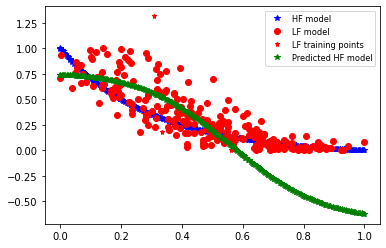

In [9]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(mu_test2_norm, U_hf_test, 'b*', linewidth = 1.5, label = 'HF model')
# plt.plot(mu_train_HF, U_hf_train,'b*', markersize = 7, label = 'HF training points')
plt.plot(mu_test_norm, U_lf_test,'ro', linewidth = 1.5, label = 'LF model')
plt.plot(mu_train_LF_norm, U_lf_train,'r*', markersize = 5, label = 'LF training points')
plt.plot(mu_test2_norm, finalModel.predict(mu_test2_norm),'g*' ,linewidth = 3,  label = 'Predicted HF model')
plt.legend(prop={'size': 8.3})
plt.show()


In [10]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs('Output_NNLF_new_noise0.025')

R2_HF=pandas.DataFrame({'R2_HF': [r2_HF]})
R2_LF=pandas.DataFrame({'R2_LF': [r2_LF]})
MSE_test_LF=pandas.DataFrame({'MSE_test_LF': [test_mse]})
MSE_test_HF=pandas.DataFrame({'MSE_test_HF': [test_mse_HF]})


R2_LF.to_csv('./Output_NNLF_new_noise0.025/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv('./Output_NNLF_new_noise0.025/test_mse.txt', header = True, index = False, sep = '\t', mode = 'a')
R2_HF.to_csv('./Output_NNLF_new_noise0.025/r2_LF_lhs.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_LF.to_csv('./Output_NNLF_new_noise0.025/mse_LF_lhs.txt', header = True, index = False, sep = '\t', mode = 'a')